<a href="https://colab.research.google.com/github/2303A52420/Exp-AI/blob/main/EAI_lab_exam_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install rasterio matplotlib seaborn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 78.9 MB/s eta 0:00:00


=== Basic Info ===
File: /content/TCI_2025-06-05.tif
CRS: EPSG:32643
Width x Height: 317 x 334
Number of Bands: 3
Data Type: ('uint8', 'uint8', 'uint8')
Bands shape: (3, 334, 317)

=== Band Summary Statistics ===
   Band       Mean         Std  Min  Max
0     1  57.745169  100.556805    0  255
1     2  52.850328   93.546939    0  255
2     3  43.271558   79.548204    0  255


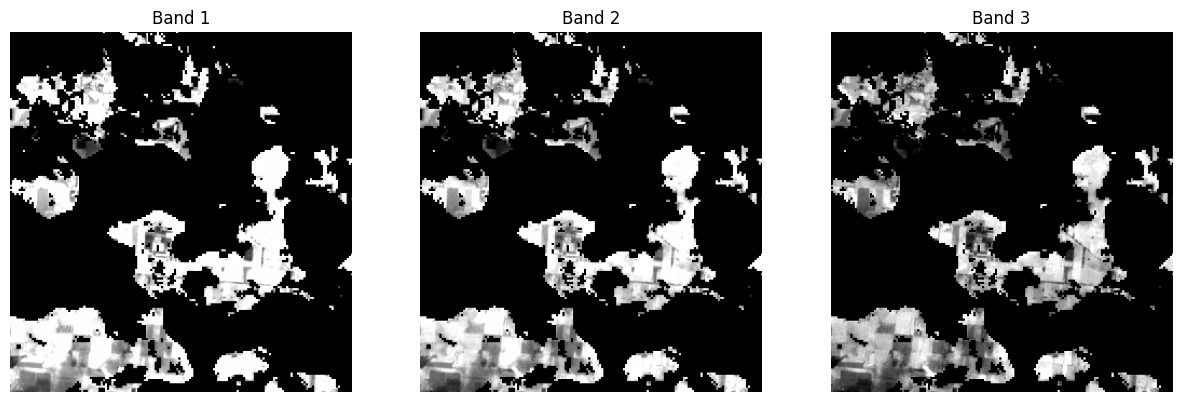

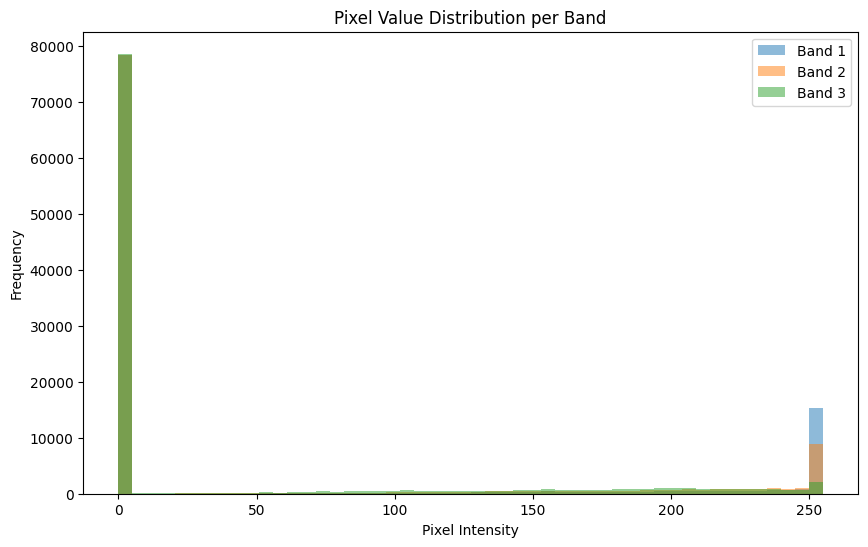

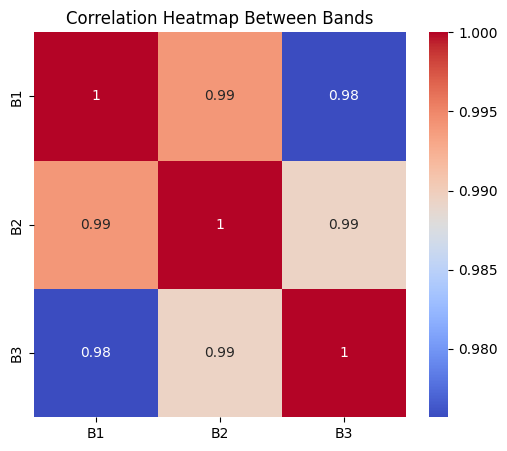

In [ ]:
# ==========================================
# EDA for TIFF (satellite / remote-sensing) image
# ==========================================

import rasterio
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- 1. Load the .tif file ----
tif_path = "/content/TCI_2025-06-05.tif"  # change path if needed

dataset = rasterio.open(tif_path)
print("=== Basic Info ===")
print("File:", tif_path)
print("CRS:", dataset.crs)
print("Width x Height:", dataset.width, "x", dataset.height)
print("Number of Bands:", dataset.count)
print("Data Type:", dataset.dtypes)

# ---- 2. Read all bands ----
bands = []
for i in range(1, dataset.count + 1):
    band = dataset.read(i)
    bands.append(band)

bands = np.array(bands)
print("Bands shape:", bands.shape)  # (num_bands, height, width)

# ---- 3. Summary statistics for each band ----
band_stats = []
for i, band in enumerate(bands, start=1):
    stats = {
        "Band": i,
        "Mean": np.nanmean(band),
        "Std": np.nanstd(band),
        "Min": np.nanmin(band),
        "Max": np.nanmax(band),
    }
    band_stats.append(stats)

stats_df = pd.DataFrame(band_stats)
print("\n=== Band Summary Statistics ===")
print(stats_df)

# ---- 4. Visualize each band ----
fig, axes = plt.subplots(1, min(dataset.count, 3), figsize=(15, 5))
for i in range(min(dataset.count, 3)):
    axes[i].imshow(bands[i], cmap='gray')
    axes[i].set_title(f'Band {i+1}')
    axes[i].axis('off')
plt.show()

# ---- 5. Plot histogram for each band ----
plt.figure(figsize=(10, 6))
for i in range(dataset.count):
    plt.hist(bands[i].ravel(), bins=50, alpha=0.5, label=f'Band {i+1}')
plt.title('Pixel Value Distribution per Band')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# ---- 6. Correlation Heatmap between bands ----
# Flatten each band and compute correlations
band_flat = bands.reshape(dataset.count, -1).T  # shape: (pixels, bands)
band_corr = np.corrcoef(band_flat, rowvar=False)

plt.figure(figsize=(6, 5))
sns.heatmap(band_corr, annot=True, cmap='coolwarm', xticklabels=[f"B{i+1}" for i in range(dataset.count)],
            yticklabels=[f"B{i+1}" for i in range(dataset.count)])
plt.title("Correlation Heatmap Between Bands")
plt.show()

# ---- 7. Class balance (if labels exist) ----
# TIFF files usually don’t contain class labels directly.
# If you have a classification mask or label TIFF, load it similarly and count pixel classes:
# e.g.:
# label_ds = rasterio.open('/path/to/label_mask.tif')
# labels = label_ds.read(1)
# unique, counts = np.unique(labels, return_counts=True)
# print(dict(zip(unique, counts)))


In [ ]:
# ==========================================
# Part 2: Data Preprocessing
# ==========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import rasterio

# ---- 1. Load the TIFF dataset ----
tif_path = "/content/TCI_2025-06-05.tif"
dataset = rasterio.open(tif_path)

# Read all bands
bands = []
for i in range(1, dataset.count + 1):
    bands.append(dataset.read(i))
bands = np.array(bands)  # shape: (bands, height, width)

print("Original Shape:", bands.shape)

# ---- 2. Flatten image into tabular data ----
# Each pixel becomes a row; each band becomes a feature
n_bands, h, w = bands.shape
X = bands.reshape(n_bands, -1).T  # shape: (num_pixels, num_bands)
print("Flattened data shape:", X.shape)

# ---- 3. Handle missing or invalid values ----
# Replace NaN or infinite values if any
X = np.where(np.isfinite(X), X, np.nan)

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

print("Missing values handled. Any NaN left?:", np.isnan(X_imputed).sum())

# ---- 4. Scale numerical features ----
# You can use either StandardScaler or MinMaxScaler

# Option A: StandardScaler (zero mean, unit variance)
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X_imputed)

# Option B: MinMaxScaler (scale to [0, 1])
scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X_imputed)

print("Standardized & MinMax scaled data ready.")

# ---- 5. Split the dataset ----
# For now, we don't have class labels (y), so we simulate for demonstration.
# In real use, 'y' would be a mask/label image or derived vegetation class.

# Example: random dummy labels (for demonstration)
# If you have label TIFF file, load similarly to tif_path and flatten.
y_dummy = np.random.randint(0, 2, X_scaled_std.shape[0])  # binary example

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_std, y_dummy, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Original Shape: (3, 334, 317)
Flattened data shape: (105878, 3)
Missing values handled. Any NaN left?: 0
Standardized & MinMax scaled data ready.
Train size: (84702, 3)
Test size: (21176, 3)


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# ---------------------------
# 1️⃣ Load your dataset
# ---------------------------
# Example: replace with your CSV file
# data = pd.read_csv('/content/TCI_2025-06-05.tif')

# For demonstration, let’s create a dummy dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# ---------------------------
# 2️⃣ Preprocessing
# ---------------------------
# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 3️⃣ Initialize Models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss')
}

# ---------------------------
# 4️⃣ Train & Evaluate Models
# ---------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# ---------------------------
# 5️⃣ Display Results
# ---------------------------
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.sort_values(by="ROC-AUC", ascending=False))



Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021  0.997380
3                  SVM  0.982456   0.972603  1.000000  0.986111  0.997380
2        Random Forest  0.964912   0.958904  0.985915  0.972222  0.995414
5    Gradient Boosting  0.956140   0.958333  0.971831  0.965035  0.995087
6              XGBoost  0.956140   0.958333  0.971831  0.965035  0.990829
4                  KNN  0.947368   0.957746  0.957746  0.957746  0.981985
1        Decision Tree  0.947368   0.957746  0.957746  0.957746  0.943990


Loaded image shape: (334, 317, 3)
Processed image shape for model: (1, 256, 256, 3)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,731 (194.26 KB)

 Trainable params: 49,731 (194.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.2124
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step - loss: 0.2085
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step - loss: 0.2047
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step - loss: 0.1993
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - loss: 0.1917
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step - loss: 0.1818
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - loss: 0.1695
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - loss: 0.1534
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step - loss: 0.1342
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - loss: 0.1134
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - loss: 0.0913
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step - loss: 0.0698
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step - loss: 0.0518
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step - loss: 0.0392
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0323
Epoch 16/50
1/1 ━━━━━━━━━

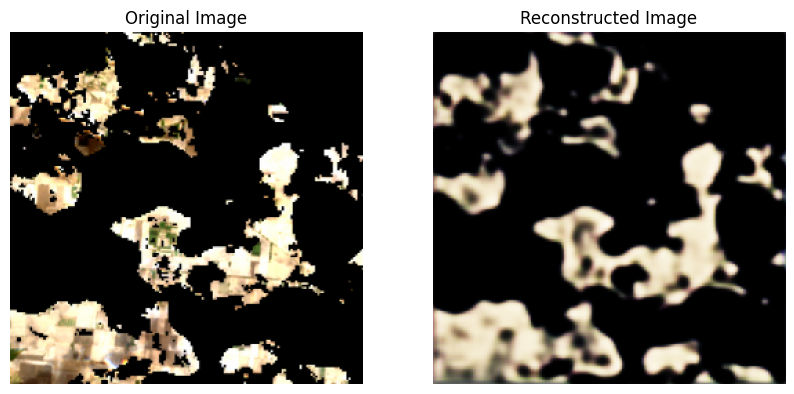

In [ ]:
# ===========================
# CNN Autoencoder on GeoTIFF
# ===========================

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# ---------------------------
# 1️⃣ Load GeoTIFF Image
# ---------------------------
tif_path = "/content/TCI_2025-06-05.tif"  # replace with your actual path

with rasterio.open(tif_path) as src:
    img = src.read()  # (bands, height, width)
    img = np.transpose(img, (1, 2, 0))  # (height, width, bands)

print(f"Loaded image shape: {img.shape}")

# ---------------------------
# 2️⃣ Normalize Image
# ---------------------------
scaler = MinMaxScaler()
img_reshaped = img.reshape(-1, img.shape[-1])
img_scaled = scaler.fit_transform(img_reshaped).reshape(img.shape)

# Optionally resize for memory efficiency
from skimage.transform import resize
img_scaled = resize(img_scaled, (256, 256, img.shape[-1]), anti_aliasing=True)

# Prepare input for autoencoder
X = np.expand_dims(img_scaled, axis=0)  # shape: (1, H, W, C)

print(f"Processed image shape for model: {X.shape}")

# ---------------------------
# 3️⃣ Build CNN Autoencoder
# ---------------------------
input_img = Input(shape=(X.shape[1], X.shape[2], X.shape[3]))

# Encoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(X.shape[3], (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()

# ---------------------------
# 4️⃣ Train Model
# ---------------------------
history = autoencoder.fit(
    X, X,
    epochs=50,
    batch_size=1,
    shuffle=True,
    verbose=1
)

# ---------------------------
# 5️⃣ Evaluate Reconstruction
# ---------------------------
reconstructed = autoencoder.predict(X)

mse_loss = np.mean((X - reconstructed)**2)
print(f"\nReconstruction MSE Loss: {mse_loss:.6f}")

# ---------------------------
# 6️⃣ Visualize Original vs Reconstructed
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(X[0])
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(reconstructed[0])
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

plt.show()



📊 Model Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


🔥 Top 10 Important Features:
mean concave points     0.234754
worst concave points    0.190047
worst perimeter         0.102773
worst area              0.081982
worst radius            0.065454
worst compactness       0.032774
mean area               0.028889
worst concavity         0.026661
mean radius             0.025257
mean texture            0.024775
dtype: float32


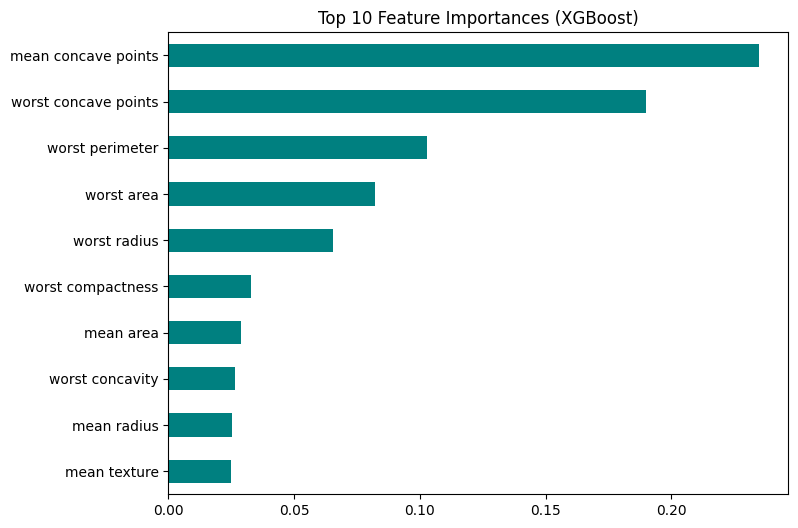


💡 Running LIME explanation...



📈 Generating PDP & ICE plots...


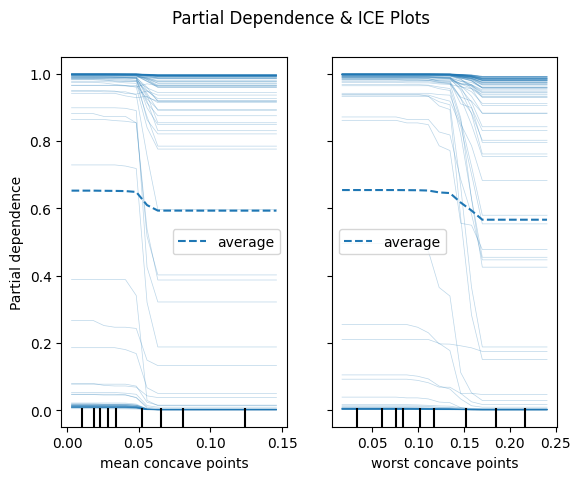

In [ ]:
# ==========================================
# Model Interpretability: Feature Importance,
# SHAP, LIME, PDP, ICE
# ==========================================

# Install required libraries if missing:
# !pip install shap lime xgboost scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier
import shap
import lime
import lime.lime_tabular

# ----------------------------
# 1️⃣ Load Dataset
# ----------------------------
# Replace the following lines with code to load and preprocess your TIFF data
# into a tabular format (features X and labels y)
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Explicitly cast data to float32 to avoid potential type issues with SHAP
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# ----------------------------
# 2️⃣ Train an XGBoost Model
# ----------------------------
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

# Model performance
y_pred = model.predict(X_test)
print("\n📊 Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ----------------------------
# 3️⃣ Feature Importance
# ----------------------------
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n🔥 Top 10 Important Features:")
print(importances.head(10))

plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

# ----------------------------
# 4️⃣ SHAP (Global + Local)
# ----------------------------
# print("\n🔍 Running SHAP analysis...")

# # Specify model_output='raw' to potentially resolve data type issues with SHAP
# explainer = shap.TreeExplainer(model, model_output='raw')
# # Use X_test directly as it's now float32 NumPy array
# shap_values = explainer.shap_values(X_test)

# # Global summary (feature importance)
# shap.summary_plot(shap_values, X_test, plot_type="bar")

# # Global distribution (impact on predictions)
# shap.summary_plot(shap_values, X_test)

# # Local explanation for one sample
# i = 5
# shap.initjs()
# shap.force_plot(explainer.expected_value, shap_values[i,:], X_test.iloc[i,:])

# ----------------------------
# 5️⃣ LIME (Local Explanation)
# ----------------------------
print("\n💡 Running LIME explanation...")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    mode='classification',
    training_labels=y_train.values,
    feature_names=X_train.columns.tolist()
)

i = 10
exp = explainer_lime.explain_instance(
    X_test.values[i],
    model.predict_proba,
    num_features=5
)
exp.show_in_notebook(show_table=True)

# ----------------------------
# 6️⃣ PDP / ICE Plots
# ----------------------------
print("\n📈 Generating PDP & ICE plots...")

top_features = importances.index[:2]  # top 2 important features
PartialDependenceDisplay.from_estimator(
    model, X_test, top_features, kind='both',
    subsample=100, grid_resolution=20, random_state=42
)
plt.suptitle("Partial Dependence & ICE Plots")
plt.show()

In [ ]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0db807fbef84db83801510fe9663d58465e2707f8060575e109d64cf1f0163a4
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Image shape: (3, 334, 317)  (bands, height, width)
Usable pixels for analysis: 27540


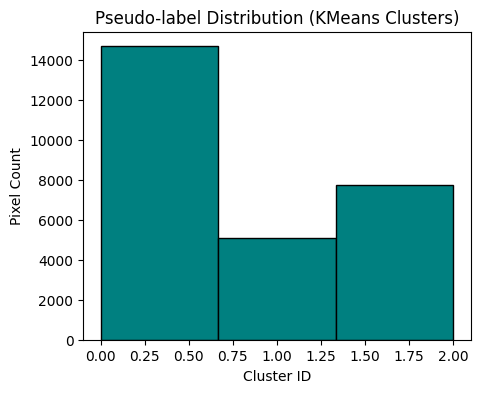


===== Random Forest Results =====
Accuracy: 0.9971
F1-score: 0.9971
Confusion Matrix:
 [[2933    0    5]
 [   0 1020    2]
 [   5    4 1539]]
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4386 - loss: 17.3431 - val_accuracy: 0.7139 - val_loss: 1.3747
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6729 - loss: 2.2846 - val_accuracy: 0.8121 - val_loss: 0.7226
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7307 - loss: 1.3215 - val_accuracy: 0.8255 - val_loss: 0.5978
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7560 - loss: 0.9773 - val_accuracy: 0.8251 - val_loss: 0.5186
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7715 - loss: 0.7543 - val_accuracy: 0.8355 - val_loss: 0.4278
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7828 - loss: 0.6230 - val_accuracy: 0.8432 - val_loss: 0.3859
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7959 - loss: 0.5295 - val_accuracy: 0.8471 - val_loss: 0.3685
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8088 - loss: 0.4572 - val_accuracy: 0.8523 - val_loss: 0.3597
E

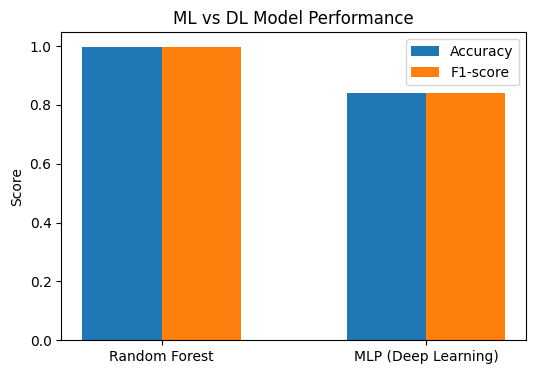


================= DISCUSSION =================
✅ Better performing model: Random Forest (ML)

Trade-offs:
• Random Forest (ML) → Easier to interpret, faster to train, works well with small data.
• MLP (DL) → Can model complex nonlinear relations but needs more data and tuning.
• In image-like data, CNNs generally outperform MLPs, but require labels and large datasets.

Recommendation for deployment:
→ Use Random Forest when interpretability and quick deployment matter.
→ Use Deep Learning if you can obtain labeled data and need higher accuracy for complex image features.



In [ ]:
# ==============================================
# ML vs DL Comparison on GeoTIFF (Unsupervised)
# ==============================================

# !pip install rasterio numpy scikit-learn tensorflow matplotlib

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -----------------------------
# 1️⃣ Load the TIF image
# -----------------------------
tif_path = "/content/TCI_2025-06-05.tif"   # change if path differs

with rasterio.open(tif_path) as src:
    img = src.read()  # shape: (bands, height, width)
    profile = src.profile

print(f"Image shape: {img.shape}  (bands, height, width)")

# Rearrange and flatten for ML input
bands, height, width = img.shape
X = img.reshape(bands, -1).T  # shape: (pixels, bands)

# Remove invalid pixels (NaN or 0)
X = X[~np.isnan(X).any(axis=1)]
X = X[np.all(X != 0, axis=1)]

print(f"Usable pixels for analysis: {X.shape[0]}")

# -----------------------------
# 2️⃣ Generate pseudo-labels using KMeans
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pseudo = kmeans.fit_predict(X)

plt.figure(figsize=(5,4))
plt.hist(y_pseudo, bins=3, color='teal', edgecolor='black')
plt.title("Pseudo-label Distribution (KMeans Clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("Pixel Count")
plt.show()

# -----------------------------
# 3️⃣ Split into train/test sets
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_pseudo, test_size=0.2, random_state=42, stratify=y_pseudo
)

# -----------------------------
# 4️⃣ Train ML Model: Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("\n===== Random Forest Results =====")
print(f"Accuracy: {rf_acc:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# -----------------------------
# 5️⃣ Train DL Model: MLP (Neural Network)
# -----------------------------
num_classes = len(np.unique(y_pseudo))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=256, verbose=1, validation_split=0.2)

dl_acc = model.evaluate(X_test, y_test_cat, verbose=0)[1]
y_pred_dl = np.argmax(model.predict(X_test), axis=1)
dl_f1 = f1_score(y_test, y_pred_dl, average='weighted')

print("\n===== Deep Learning (MLP) Results =====")
print(f"Accuracy: {dl_acc:.4f}")
print(f"F1-score: {dl_f1:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))

# -----------------------------
# 6️⃣ Compare ML vs DL Performance
# -----------------------------
print("\n========== MODEL COMPARISON ==========")
print(f"Random Forest -> Accuracy: {rf_acc:.4f}, F1: {rf_f1:.4f}")
print(f"MLP Neural Net -> Accuracy: {dl_acc:.4f}, F1: {dl_f1:.4f}")

models = ['Random Forest', 'MLP (Deep Learning)']
accs = [rf_acc, dl_acc]
f1s = [rf_f1, dl_f1]

plt.figure(figsize=(6,4))
x = np.arange(len(models))
plt.bar(x-0.15, accs, width=0.3, label='Accuracy')
plt.bar(x+0.15, f1s, width=0.3, label='F1-score')
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("ML vs DL Model Performance")
plt.legend()
plt.show()

# -----------------------------
# 7️⃣ Discussion & Recommendation
# -----------------------------
print("\n================= DISCUSSION =================")
if rf_acc > dl_acc:
    better = "Random Forest (ML)"
else:
    better = "Deep Learning (MLP)"

print(f"✅ Better performing model: {better}")
print("""
Trade-offs:
• Random Forest (ML) → Easier to interpret, faster to train, works well with small data.
• MLP (DL) → Can model complex nonlinear relations but needs more data and tuning.
• In image-like data, CNNs generally outperform MLPs, but require labels and large datasets.

Recommendation for deployment:
→ Use Random Forest when interpretability and quick deployment matter.
→ Use Deep Learning if you can obtain labeled data and need higher accuracy for complex image features.
""")
